In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,d041b_00000,0,664.395357,bald,1,98988.537222
1,1,d041b_00000,1,663.611181,bald,1,98988.537222
2,2,d041b_00000,2,654.466871,bald,1,98988.537222
3,3,d041b_00000,3,652.914693,bald,1,98988.537222
4,4,d041b_00000,4,645.993785,bald,1,98988.537222
...,...,...,...,...,...,...,...
13680,13680,d041b_00034,386,112.623949,random,5,102539.527754
13681,13681,d041b_00034,387,112.636390,random,5,102539.527754
13682,13682,d041b_00034,388,112.767632,random,5,102539.527754
13683,13683,d041b_00034,389,112.693331,random,5,102539.527754


In [3]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
11730,11730,d041b_00030,0,664.395357,random,1,115590.573348
11731,11731,d041b_00030,1,663.092698,random,1,115590.573348
11732,11732,d041b_00030,2,662.773295,random,1,115590.573348
11733,11733,d041b_00030,3,662.598096,random,1,115590.573348
11734,11734,d041b_00030,4,661.294748,random,1,115590.573348
...,...,...,...,...,...,...,...
13680,13680,d041b_00034,386,112.623949,random,5,102539.527754
13681,13681,d041b_00034,387,112.636390,random,5,102539.527754
13682,13682,d041b_00034,388,112.767632,random,5,102539.527754
13683,13683,d041b_00034,389,112.693331,random,5,102539.527754


In [4]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{row.avg:.2f} ± {row.stdv:.2f}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

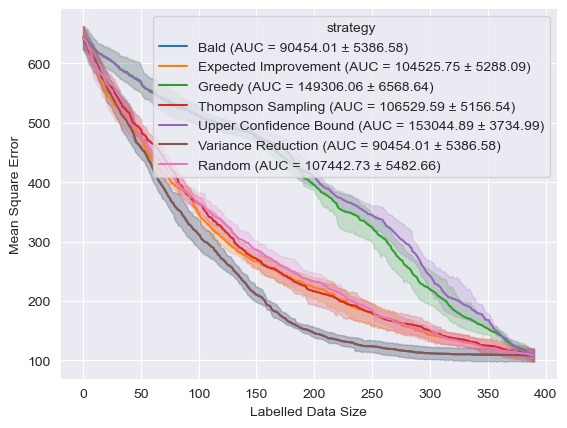

In [5]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Mean Square Error")
plt.xlabel("Labelled Data Size")
# _ = plt.xticks(np.arange(0,26), np.arange(0,26)*10 + 20, rotation=45)

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
    

for spine in ax.spines.values():
    spine.set_visible(False)